<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>Hypothesis 1 검정: BTC 가격 변동과 GPU 가격 변동의 단기/장기 관계</mark></b></span><br><br>

<b>[분석 목적]</b><br>
• 전체 GPU 가격지수의 검정용 주간 로그수익률(<b>ret_all_w['GPU_ALL']</b>)을 사용해 BTC-KRW 변동과의 단기 공변동을 검정한다.<br>
• 조교 피드백을 반영해 BTC 효과가 즉시 나타나는지, 혹은 몇 주 시차를 두고 나타나는지 <b>lag 0~8주</b>로 확인한다.<br>
• 환율(<b>fx_ret</b>)과 AI/반도체 수요 proxy(<b>nvda_ret</b>)를 통제해 BTC 효과와 외부 수요 효과를 분리한다.<br>
• 다중공선성은 <b>VIF</b>로 점검하고, 편상관관계적 해석은 <b>partial correlation + 다변량 회귀계수</b>로 보조 설명한다.<br>
• 보조적인 선행성 검정은 단순 이변량 Granger가 아니라 <b>VAR 기반 다변량 Granger causality</b>를 사용한다.<br>
• 장기 관계는 가격 level이 아니라 <b>log index / log price level</b>을 이용해 ADF, Engle-Granger, ECM 순서로 확인한다.<br><br>

<b>[ETC-KRW 보조 EDA 추가 이유]</b><br>
BTC는 현대 시점에서 GPU 채굴 직접 수요라기보다 암호화폐 시장심리 proxy에 가깝다. 반면 <b>ETC-KRW</b>는 Ethereum Classic으로, GPU 채굴과의 연결 가능성이 상대적으로 더 직접적일 수 있다. 다만 시장 규모와 유동성 측면에서 BTC보다 대표성이 약하므로, 본 가설의 메인 설명변수로 넣지 않고 <b>도메인 방어용 보조 EDA</b>로만 확인한다.<br><br>

<b>[도메인 방어 논리]</b><br>
본 기간은 2024~2026년으로 ETH Merge 이후이다. 따라서 BTC는 GPU 채굴 수요의 직접 원인이라기보다 <b>암호화폐 시장 심리와 위험자산 수요를 대표하는 macro crypto proxy</b>로 해석한다. 직접 채굴 수요 효과를 주장하지 않고, BTC 시장 변동이 GPU 가격지수와 통계적으로 동행/선행하는지를 검정한다.<br><br>

<span style="color: #e53e3e; font-size: 18px;"><b>핵심: 단기 검정은 ret_w, 장기 검정은 index level, BTC 시차 효과는 distributed lag regression으로 본다. ETC-KRW는 메인 검정이 아니라 보조 EDA로만 사용한다.</b></span>
</div>

In [11]:
# Hypothesis 1 setup
# read data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import statsmodels.api as sm
import statsmodels.formula.api as smf

# 시계열 데이터의 stationary 판단
from statsmodels.tsa.stattools import adfuller, coint

# Vector Autoregression: 여러 시계열 변수의 상호의존성과 예측적 선행성 점검
from statsmodels.tsa.api import VAR

# 다중공선성 VIF 판단
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 기존 전처리 파이프라인에서 저장한 output 폴더
OUT = Path("outputs")

# Hypothesis 1 결과 저장 폴더
H1_OUT = OUT / "hypo1"
H1_OUT.mkdir(parents=True, exist_ok=True)

MAX_LAG = 8      # BTC 반영 시차: 0~8주
HAC_LAG = 4      # Newey-West HAC 표준오차 lag

# 사용할 핵심 컬럼
GPU_RET_COL = "GPU_ALL"
MKT_RET_COLS = ["btc_krw_ret", "fx_ret", "nvda_ret"]

# 한국어 폰트 설정 및 -기호, 경고문 안 뜨게 설정
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "MalGun Gothic"
plt.rcParams["axes.unicode_minus"] = False

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>0. GPU output과 외부 시장변수 로드</mark></b></span><br><br>
<b>[왜 이 과정이 필요한가]</b><br>
Hypothesis 1의 단기 검정은 이미 만들어둔 <b>ret_all_w['GPU_ALL']</b>을 사용한다. 이 값은 Chain Matched Jevons Index에서 나온 전체 GPU 시장의 주간 로그수익률이므로, 가격 전처리나 0값 처리 과정을 다시 반복하지 않는다.<br><br>
외부 시장변수는 yfinance에서 불러온 뒤 GPU output과 같은 <b>W-SUN 주간 단위</b>로 맞춘다. 다만 BTC/ETC는 주말에도 거래되고 NVDA/환율은 주말 거래가 없으므로, 특정 요일 종가만 쓰면 미세한 lead-lag 불일치가 생길 수 있다. 따라서 여기서는 <b>주간 평균 log level의 차분</b>을 사용해 주간 수익률을 만든다.<br><br>
<b>[해석 기준]</b><br>
이 셀의 목적은 검정이 아니라 분석 단위 정렬이다. 이후 모든 단기 검정은 <b>weekly log return</b>, 장기 검정은 <b>weekly log level</b>을 기준으로 수행한다.
</div>

ret_all_w


,CPU_ALL,GPU_ALL,RAM_ALL
date,,,
2024-03-03,NaN,NaN,NaN
2024-03-10,-0.001478,0.002189,0.002896
2024-03-17,0.000508,0.003092,0.001473
2024-03-24,0.000673,0.002050,-0.003016
2024-03-31,0.001044,0.001093,-0.001508


market weekly returns


,btc_krw_ret,etc_krw_ret,fx_ret,nvda_ret
Date,,,,
2024-03-03,NaN,NaN,NaN,NaN
2024-03-10,0.066505,0.110523,-0.005180,0.067045
2024-03-17,0.040157,-0.062324,-0.010337,0.009760
2024-03-24,-0.056947,-0.123070,0.014201,0.021430
2024-03-31,0.075551,0.093258,0.008682,0.013723


market weekly log levels


Ticker,btc_krw,etc_krw,usdkrw,nvda
Date,,,,
2024-03-03,18.237997,10.680341,7.196836,4.409505
2024-03-10,18.304502,10.790864,7.191656,4.476550
2024-03-17,18.344659,10.728540,7.181319,4.486310
2024-03-24,18.287712,10.605470,7.195521,4.507740
2024-03-31,18.363263,10.698728,7.204203,4.521463


saved: outputs\mkt_w.csv outputs\mkt_log_level_w.csv


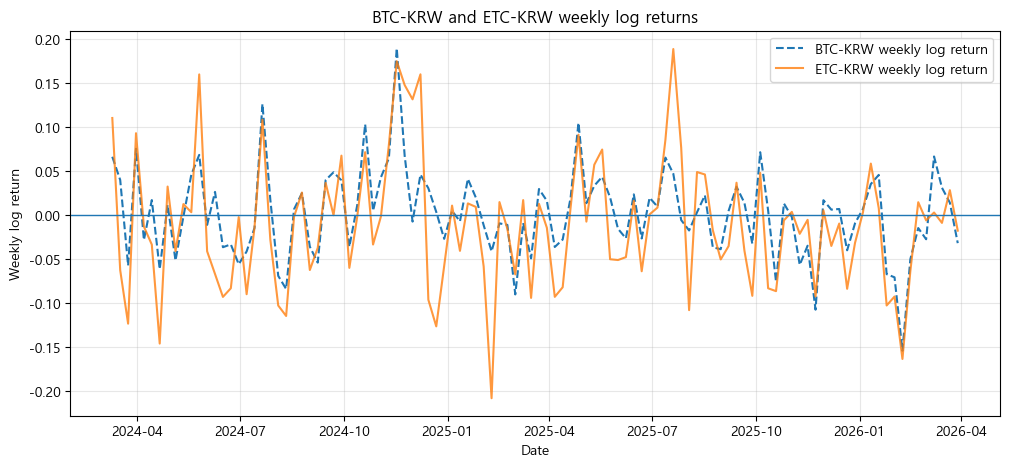

In [12]:
# ============================================================
# 0. GPU output과 외부 시장변수 로드
# ============================================================

ret_all_w = (
    pd.read_csv(OUT / "ret_all_w.csv", parse_dates=["date"])
    .set_index("date")
    .sort_index()
)

idx_all_w = (
    pd.read_csv(OUT / "idx_all_w.csv", parse_dates=["date"])
    .set_index("date")
    .sort_index()
)

# BTC-KRW, ETC-KRW, USD/KRW, NVDA 주간 변수 생성
# ETC-KRW는 메인 회귀가 아니라 GPU mining coin 관련 도메인 방어용 EDA에만 사용한다.
import yfinance as yf

MKT_TICKERS = {
    "BTC-KRW": "btc_krw",
    "ETC-KRW": "etc_krw",
    "KRW=X": "usdkrw",
    "NVDA": "nvda",
}

START_DATE = "2024-03-01"
END_DATE = "2026-03-31"

mkt_px = yf.download(
    list(MKT_TICKERS.keys()),
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False,
)["Close"].rename(columns=MKT_TICKERS)

# W-SUN: GPU output과 같은 주간 bucket 기준
WEEKLY_FREQ = "W-SUN"

# 주간 평균 log-price level
mkt_log_level_w = np.log(mkt_px).resample(WEEKLY_FREQ).mean()
mkt_log_level_w = mkt_log_level_w.loc[pd.to_datetime(START_DATE):pd.to_datetime(END_DATE)]

# Hypothesis test용 주간 log return
mkt_w = pd.DataFrame(index=mkt_log_level_w.index)
mkt_w["btc_krw_ret"] = mkt_log_level_w["btc_krw"].diff()
mkt_w["etc_krw_ret"] = mkt_log_level_w["etc_krw"].diff()
mkt_w["fx_ret"] = mkt_log_level_w["usdkrw"].diff()
mkt_w["nvda_ret"] = mkt_log_level_w["nvda"].diff()

# level 분석/공적분용 log level도 저장
mkt_w.to_csv(OUT / "mkt_w.csv")
mkt_log_level_w.to_csv(OUT / "mkt_log_level_w.csv")

print("ret_all_w")
display(ret_all_w.head())

print("market weekly returns")
display(mkt_w.head())

print("market weekly log levels")
display(mkt_log_level_w.head())

print("saved:", OUT / "mkt_w.csv", OUT / "mkt_log_level_w.csv")

plt.figure(figsize=(12, 5))
plt.plot(mkt_w.index, mkt_w["btc_krw_ret"], linestyle="--", label="BTC-KRW weekly log return")
plt.plot(mkt_w.index, mkt_w["etc_krw_ret"], alpha=0.8, label="ETC-KRW weekly log return")
plt.axhline(0, linewidth=1)
plt.title("BTC-KRW and ETC-KRW weekly log returns")
plt.xlabel("Date")
plt.ylabel("Weekly log return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>0-1. ETC-KRW 보조 EDA</mark></b></span><br><br>
<b>[왜 ETC-KRW를 따로 보는가]</b><br>
BTC는 2024~2026년 분석기간에서 GPU 채굴 수요의 직접 변수라고 보기 어렵다. 그래서 BTC는 암호화폐 시장심리 또는 위험자산 선호를 대표하는 proxy로 사용한다. 반면 <b>ETC-KRW</b>는 GPU 채굴 가능성과 더 직접적으로 연결될 수 있으므로, 발표에서 “왜 BTC를 썼는가?”라는 질문에 대비하기 위한 <b>도메인 보조 EDA</b>로 확인한다.<br><br>
<b>[왜 메인 회귀에는 넣지 않는가]</b><br>
ETC는 BTC보다 시장 규모와 대표성이 작고, 본 가설은 BTC가 암호화폐 시장 전체 심리 proxy로 작동하는지를 검정하는 구조이다. 따라서 ETC는 메인 설명변수로 넣기보다, BTC와 ETC가 얼마나 같이 움직이는지, ETC가 GPU 수익률과 어떤 lag에서 더 강한 단순 상관을 보이는지를 확인하는 보조 분석으로 둔다.<br><br>
<b>[실행 후 해석]</b><br>
• BTC-ETC 상관이 높으면 BTC가 암호화폐 시장 전체 변동을 대표한다는 방어 논리가 강화된다.<br>
• ETC-GPU lag 상관이 BTC-GPU보다 훨씬 강하면, 보고서에서 “BTC보다 GPU-mining coin proxy가 더 직접적인 대안일 수 있다”는 한계로 적는다.<br>
• ETC-GPU 관계도 약하면, post-Merge 이후 GPU 가격은 채굴 수요보다 AI/환율/제품주기 요인의 영향을 더 받을 수 있다는 해석이 가능하다.
</div>

BTC-KRW vs ETC-KRW return correlation
0.7457
ETC-KRW lag correlation with GPU return


,lag_week,corr_gpu_etc,n
0,0,-0.1926,105
1,1,-0.1022,104
2,2,0.0366,103
3,3,0.0358,102
4,4,0.0271,101
5,5,0.0479,100
6,6,0.0203,99
7,7,0.0463,98
8,8,0.0162,97


ETC-KRW EDA summary


,metric,value,interpretation
0,corr_btc_etc_return,0.745652,BTC-KRW와 ETC-KRW가 같은 crypto sentiment를 공유하는지 확인
1,max_abs_corr_gpu_etc_lag_week,0.000000,GPU return과 ETC-KRW lag return의 절대상관이 가장 큰 시차
2,max_abs_corr_gpu_etc_value,-0.192636,해당 시차에서의 GPU-ETC 단순 상관계수


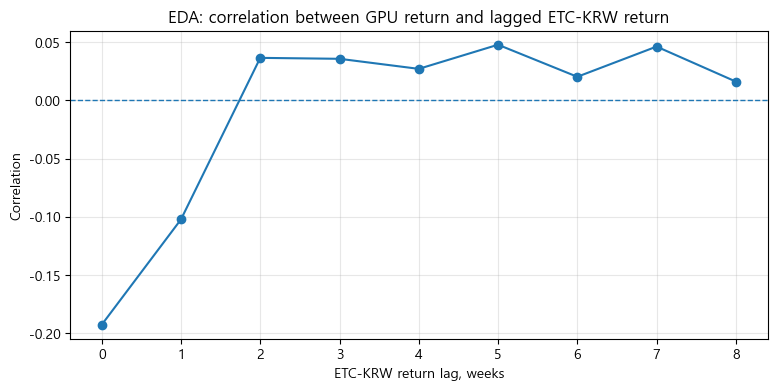

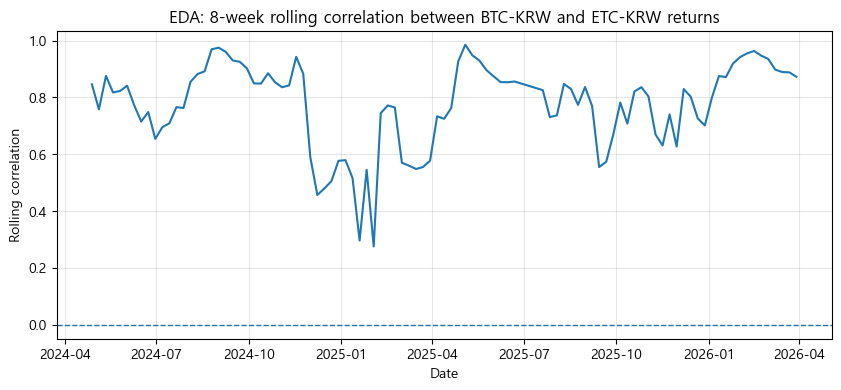

In [13]:
# ============================================================
# 0-1. ETC-KRW 보조 EDA
#      메인 검정에 넣지 않고, 도메인 방어용으로만 확인한다.
# ============================================================

etc_eda = (
    ret_all_w[[GPU_RET_COL]]
    .rename(columns={GPU_RET_COL: "gpu_ret"})
    .join(mkt_w[["btc_krw_ret", "etc_krw_ret"]], how="inner")
    .dropna()
    .copy()
)

# BTC와 ETC가 같은 crypto sentiment를 공유하는지 확인
crypto_corr = etc_eda[["btc_krw_ret", "etc_krw_ret"]].corr().loc["btc_krw_ret", "etc_krw_ret"]

# ETC 자체가 GPU 수익률과 어느 시차에서 더 강하게 움직이는지 확인
etc_lag_rows = []
for k in range(MAX_LAG + 1):
    col = f"etc_krw_ret_l{k}"
    etc_eda[col] = etc_eda["etc_krw_ret"].shift(k)
    temp = etc_eda[["gpu_ret", col]].dropna()
    etc_lag_rows.append({
        "lag_week": k,
        "corr_gpu_etc": temp["gpu_ret"].corr(temp[col]),
        "n": len(temp),
    })

etc_lag_corr = pd.DataFrame(etc_lag_rows)
etc_max_row = etc_lag_corr.loc[etc_lag_corr["corr_gpu_etc"].abs().idxmax()]

etc_eda_summary = pd.DataFrame([
    {
        "metric": "corr_btc_etc_return",
        "value": crypto_corr,
        "interpretation": "BTC-KRW와 ETC-KRW가 같은 crypto sentiment를 공유하는지 확인",
    },
    {
        "metric": "max_abs_corr_gpu_etc_lag_week",
        "value": int(etc_max_row["lag_week"]),
        "interpretation": "GPU return과 ETC-KRW lag return의 절대상관이 가장 큰 시차",
    },
    {
        "metric": "max_abs_corr_gpu_etc_value",
        "value": float(etc_max_row["corr_gpu_etc"]),
        "interpretation": "해당 시차에서의 GPU-ETC 단순 상관계수",
    },
])

print("BTC-KRW vs ETC-KRW return correlation")
print(round(crypto_corr, 4))

print("ETC-KRW lag correlation with GPU return")
display(etc_lag_corr.round(4))

print("ETC-KRW EDA summary")
display(etc_eda_summary)

etc_lag_corr.to_csv(H1_OUT / "h1_etc_lag_correlation_eda.csv", index=False)
etc_eda_summary.to_csv(H1_OUT / "h1_etc_eda_summary.csv", index=False)

plt.figure(figsize=(9, 4))
plt.plot(etc_lag_corr["lag_week"], etc_lag_corr["corr_gpu_etc"], marker="o")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("EDA: correlation between GPU return and lagged ETC-KRW return")
plt.xlabel("ETC-KRW return lag, weeks")
plt.ylabel("Correlation")
plt.grid(True, alpha=0.3)
plt.show()

rolling_corr = etc_eda["btc_krw_ret"].rolling(8).corr(etc_eda["etc_krw_ret"])
plt.figure(figsize=(10, 4))
plt.plot(rolling_corr.index, rolling_corr)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("EDA: 8-week rolling correlation between BTC-KRW and ETC-KRW returns")
plt.xlabel("Date")
plt.ylabel("Rolling correlation")
plt.grid(True, alpha=0.3)
plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>1. Hypo 1 단기 검정용 데이터셋 구성</mark></b></span><br><br>
<b>[왜 이 데이터셋을 만드는가]</b><br>
단기 관계 검정에서는 가격 level을 그대로 쓰면 추세 때문에 허위 상관이 생길 수 있다. 따라서 이미 output으로 만들어진 <b>GPU_ALL 주간 로그수익률</b>을 종속변수로 사용하고, BTC-KRW 수익률의 현재값과 lag 값을 설명변수로 사용한다.<br><br>
<b>[통제변수 의미]</b><br>
• <b>fx_ret</b>: GPU 가격이 원화 기준이므로 환율 변동 효과를 제거한다.<br>
• <b>nvda_ret</b>: AI/반도체 수요가 BTC와 GPU 가격을 동시에 움직이는 교란 가능성을 통제한다.<br>
• <b>gpu_ret_l1</b>: GPU 가격 자체의 단기 관성을 통제한다.<br><br>
<b>[해석 기준]</b><br>
이후 BTC lag 계수는 환율, NVDA, GPU 자기시차의 영향을 제거한 뒤 남는 <b>BTC와 GPU 수익률의 조건부 관계</b>로 해석한다.
</div>

In [14]:
# ============================================================
# 1. Hypo 1 단기 검정용 데이터셋 구성
#    기존 output ret_all_w는 bridge smoothing이 빠진 검정용 인접 주간 로그수익률이다.
# ============================================================

h1 = (
    ret_all_w[[GPU_RET_COL]]
    .rename(columns={GPU_RET_COL: "gpu_ret"})
    .join(mkt_w[MKT_RET_COLS], how="inner")
    .sort_index()
)

# GPU 가격 자체의 단기 관성 통제
h1["gpu_ret_l1"] = h1["gpu_ret"].shift(1)

# BTC 시차 변수 생성
for k in range(MAX_LAG + 1):
    h1[f"btc_krw_ret_l{k}"] = h1["btc_krw_ret"].shift(k)

print("Hypo 1 regression dataset")
display(h1.head(12))

btc_lag_cols = [f"btc_krw_ret_l{k}" for k in range(MAX_LAG + 1)]
reg_cols = ["gpu_ret"] + btc_lag_cols + ["fx_ret", "nvda_ret", "gpu_ret_l1"]

sample_h1 = pd.DataFrame({
    "item": ["raw_join_weeks", "complete_regression_weeks"],
    "n": [len(h1), h1[reg_cols].dropna().shape[0]],
})

print("sample size check")
display(sample_h1)

h1.to_csv(H1_OUT / "h1_regression_dataset.csv")
sample_h1.to_csv(H1_OUT / "h1_sample_check.csv", index=False)

Hypo 1 regression dataset


,gpu_ret,btc_krw_ret,fx_ret,nvda_ret,gpu_ret_l1,btc_krw_ret_l0,btc_krw_ret_l1,btc_krw_ret_l2,btc_krw_ret_l3,btc_krw_ret_l4,btc_krw_ret_l5,btc_krw_ret_l6,btc_krw_ret_l7,btc_krw_ret_l8
2024-03-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-03-10,0.002189,0.066505,-0.005180,0.067045,NaN,0.066505,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-03-17,0.003092,0.040157,-0.010337,0.009760,0.002189,0.040157,0.066505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-03-24,0.002050,-0.056947,0.014201,0.021430,0.003092,-0.056947,0.040157,0.066505,NaN,NaN,NaN,NaN,NaN,NaN
2024-03-31,0.001093,0.075551,0.008682,0.013723,0.002050,0.075551,-0.056947,0.040157,0.066505,NaN,NaN,NaN,NaN,NaN
2024-04-07,-0.000115,-0.028035,0.003322,-0.038739,0.001093,-0.028035,0.075551,-0.056947,0.040157,0.066505,NaN,NaN,NaN,NaN
2024-04-14,0.000292,0.017280,0.005436,-0.009952,-0.000115,0.017280,-0.028035,0.075551,-0.056947,0.040157,0.066505,NaN,NaN,NaN
2024-04-21,0.002427,-0.061172,0.018837,-0.047657,0.000292,-0.061172,0.017280,-0.028035,0.075551,-0.056947,0.040157,0.066505,NaN,NaN
2024-04-28,-0.000934,0.011898,-0.006040,-0.014769,0.002427,0.011898,-0.061172,0.017280,-0.028035,0.075551,-0.056947,0.040157,0.066505,NaN
2024-05-05,-0.000639,-0.051308,0.000705,0.047370,-0.000934,-0.051308,0.011898,-0.061172,0.017280,-0.028035,0.075551,-0.056947,0.040157,0.066505


sample size check


,item,n
0,raw_join_weeks,109
1,complete_regression_weeks,96


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>2. 시차 상관분석: BTC lag별 GPU 반응 탐색</mark></b></span><br><br>
<b>[왜 이 기법을 쓰는가]</b><br>
조교 피드백의 핵심은 BTC 가격 변동이 GPU 가격에 바로 반영되지 않고 <b>재고 소진, 유통망 가격 조정, 소비자 수요 반응</b>을 거쳐 몇 주 뒤 반영될 수 있다는 점이다. 그래서 BTC 수익률을 0~8주 lag로 밀어가며 GPU 수익률과의 단순 상관을 먼저 확인한다.<br><br>
<b>[주의]</b><br>
이 단계는 최종 검정이 아니라 EDA이다. 통제변수와 자기상관 보정이 빠져 있으므로, 여기서 상관이 커 보이더라도 최종 주장은 뒤의 distributed lag regression으로 해야 한다.<br><br>
<b>[실행 후 해석]</b><br>
절대상관이 가장 큰 lag는 “GPU 시장이 BTC 변화에 가장 강하게 동행한 후보 시차”로 해석한다. 단, p-value 기반 결론은 회귀분석과 공동 유의성 검정에서 판단한다.
</div>

BTC lag별 GPU 수익률과의 상관계수


,lag_week,corr_gpu_btc,n
0,0,-0.2216,105
1,1,-0.0676,104
2,2,0.0732,103
3,3,0.0563,102
4,4,0.0717,101
5,5,0.0675,100
6,6,0.0092,99
7,7,0.0685,98
8,8,0.0541,97


max abs correlation lag = 0 week, corr = -0.2216


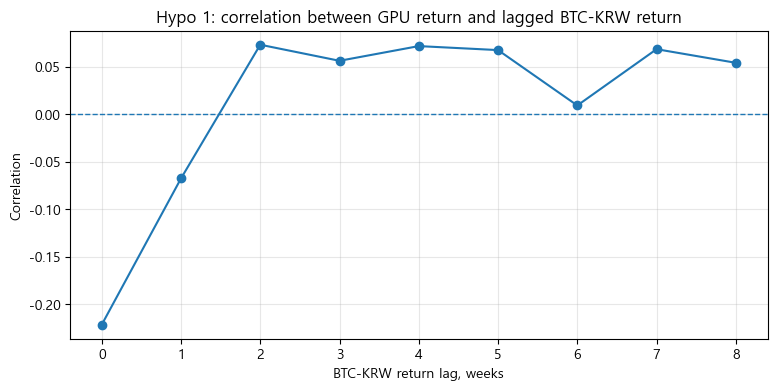

In [15]:
# ============================================================
# 2. 시차 상관분석: BTC lag별 GPU 반응 탐색
#    최종 검정이 아니라, 어느 시차에서 반응이 강한지 보는 EDA이다.
# ============================================================

lag_corr_rows = []

for k in range(MAX_LAG + 1):
    col = f"btc_krw_ret_l{k}"
    temp = h1[["gpu_ret", col]].dropna()
    lag_corr_rows.append({
        "lag_week": k,
        "corr_gpu_btc": temp["gpu_ret"].corr(temp[col]),
        "n": len(temp),
    })

lag_corr = pd.DataFrame(lag_corr_rows)
max_corr_row = lag_corr.loc[lag_corr["corr_gpu_btc"].abs().idxmax()]

print("BTC lag별 GPU 수익률과의 상관계수")
display(lag_corr.round(4))
print(f"max abs correlation lag = {int(max_corr_row['lag_week'])} week, corr = {max_corr_row['corr_gpu_btc']:.4f}")

lag_corr.to_csv(H1_OUT / "h1_lag_correlation.csv", index=False)

plt.figure(figsize=(9, 4))
plt.plot(lag_corr["lag_week"], lag_corr["corr_gpu_btc"], marker="o")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Hypo 1: correlation between GPU return and lagged BTC-KRW return")
plt.xlabel("BTC-KRW return lag, weeks")
plt.ylabel("Correlation")
plt.grid(True, alpha=0.3)
plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>3. 편상관 보조분석: 통제변수를 제거한 BTC-GPU 관계</mark></b></span><br><br>
<b>[왜 이 기법을 쓰는가]</b><br>
다변량 회귀의 BTC lag 계수는 이미 환율, NVDA, GPU 자기시차를 통제한 조건부 관계이다. 하지만 발표에서 “편상관관계와 같은 의미인가?”라는 질문이 나올 수 있으므로, 각 BTC lag에 대해 통제변수의 영향을 먼저 제거한 뒤 잔차끼리의 상관을 계산한다.<br><br>
<b>[해석 기준]</b><br>
partial correlation이 단순 lag correlation보다 크게 줄어들면, 기존 상관의 상당 부분이 환율, NVDA, 또는 GPU 자기시차에 의해 설명되었을 가능성이 있다. 반대로 통제 후에도 특정 lag에서 상관이 유지되면 BTC 고유의 조건부 관계가 남아있다는 보조 근거가 된다.<br><br>
<b>[주의]</b><br>
partial correlation은 보조 EDA이고, 최종 p-value 판단은 HAC 표준오차를 적용한 distributed lag regression과 BTC lag 공동 유의성 검정에서 한다.
</div>

Partial correlation by BTC lag after controlling FX, NVDA, and GPU lag 1


,lag_week,partial_corr_gpu_btc,n
0,0,0.0381,103
1,1,0.1560,103
2,2,0.1855,102
3,3,0.0043,101
4,4,0.0064,100
5,5,0.0235,99
6,6,-0.0504,98
7,7,0.1121,97
8,8,0.0427,96


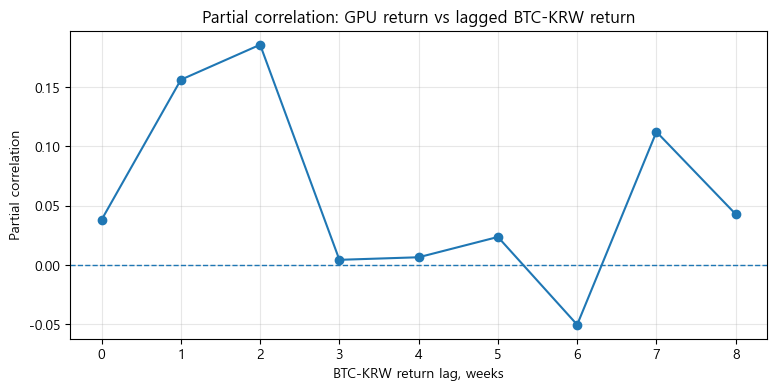

In [16]:
# ============================================================
# 3. 편상관 보조분석: controls를 제거한 뒤 BTC lag와 GPU return의 잔차상관 계산
# ============================================================

def residualize(y, X):
    X_const = sm.add_constant(X.astype(float))
    return sm.OLS(y.astype(float), X_const).fit().resid

partial_rows = []
control_cols = ["fx_ret", "nvda_ret", "gpu_ret_l1"]

for k in range(MAX_LAG + 1):
    btc_col = f"btc_krw_ret_l{k}"
    temp = h1[["gpu_ret", btc_col] + control_cols].dropna().copy()
    gpu_resid = residualize(temp["gpu_ret"], temp[control_cols])
    btc_resid = residualize(temp[btc_col], temp[control_cols])
    partial_rows.append({
        "lag_week": k,
        "partial_corr_gpu_btc": pd.Series(gpu_resid).corr(pd.Series(btc_resid)),
        "n": len(temp),
    })

partial_corr = pd.DataFrame(partial_rows)

print("Partial correlation by BTC lag after controlling FX, NVDA, and GPU lag 1")
display(partial_corr.round(4))
partial_corr.to_csv(H1_OUT / "h1_partial_corr_by_lag.csv", index=False)

plt.figure(figsize=(9, 4))
plt.plot(partial_corr["lag_week"], partial_corr["partial_corr_gpu_btc"], marker="o")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Partial correlation: GPU return vs lagged BTC-KRW return")
plt.xlabel("BTC-KRW return lag, weeks")
plt.ylabel("Partial correlation")
plt.grid(True, alpha=0.3)
plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>4. Distributed Lag Regression: Hypo 1 메인 검정</mark></b></span><br><br>
<b>[왜 이 기법을 쓰는가]</b><br>
Hypothesis 1은 단순히 BTC와 GPU가 같은 주에 같이 움직였는지가 아니라, BTC 변동이 <b>여러 주의 시차를 두고</b> GPU 가격에 반영되는지를 검정한다. 그래서 BTC 수익률의 현재값과 1~8주 lag를 한 회귀식에 함께 넣는 <b>distributed lag regression</b>을 사용한다.<br><br>
<b>[통계적 의미]</b><br>
각 BTC lag 계수는 환율, NVDA, GPU 자기시차를 통제한 뒤 해당 시차의 BTC 수익률이 GPU 수익률과 갖는 조건부 관계이다. 이는 편상관관계의 회귀분석 버전이라고 이해할 수 있다.<br><br>
<b>[왜 HAC 표준오차를 쓰는가]</b><br>
주간 시계열 회귀에서는 잔차의 자기상관과 이분산이 생길 수 있다. 일반 OLS 표준오차를 그대로 쓰면 p-value가 과도하게 작아질 수 있으므로, Newey-West 방식의 <b>HAC 표준오차</b>로 보정한다.<br><br>
<b>[실행 후 해석]</b><br>
• 특정 lag의 계수가 유의하면 해당 시차에서 BTC 변화가 GPU 변화와 조건부로 연결되어 있다는 뜻이다.<br>
• 여러 lag가 동시에 약하게 작용할 수 있으므로, 단일 계수보다 다음 단계의 <b>BTC lag 공동 유의성 검정</b>이 더 중요하다.
</div>

                            OLS Regression Results                            
Dep. Variable:                gpu_ret   R-squared:                       0.562
Model:                            OLS   Adj. R-squared:                  0.499
Method:                 Least Squares   F-statistic:                     7.745
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.91e-09
Time:                        17:20:12   Log-Likelihood:                 349.84
No. Observations:                  96   AIC:                            -673.7
Df Residuals:                      83   BIC:                            -640.3
Df Model:                          12                                         
Covariance Type:                  HAC                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.0001      0.001      0.

,term,coef,se_HAC,t_HAC,p_value_HAC,lag_week
1,btc_krw_ret_l0,-0.00322,0.01498,-0.21507,0.82971,0
2,btc_krw_ret_l1,0.01804,0.01334,1.35218,0.17632,1
3,btc_krw_ret_l2,0.03121,0.02110,1.47959,0.13898,2
4,btc_krw_ret_l3,-0.01855,0.01030,-1.80173,0.07159,3
5,btc_krw_ret_l4,0.00531,0.01386,0.38303,0.70170,4
6,btc_krw_ret_l5,0.00306,0.01020,0.29973,0.76438,5
7,btc_krw_ret_l6,-0.02101,0.00883,-2.38088,0.01727,6
8,btc_krw_ret_l7,0.02586,0.01475,1.75281,0.07964,7
9,btc_krw_ret_l8,0.00624,0.01509,0.41376,0.67905,8


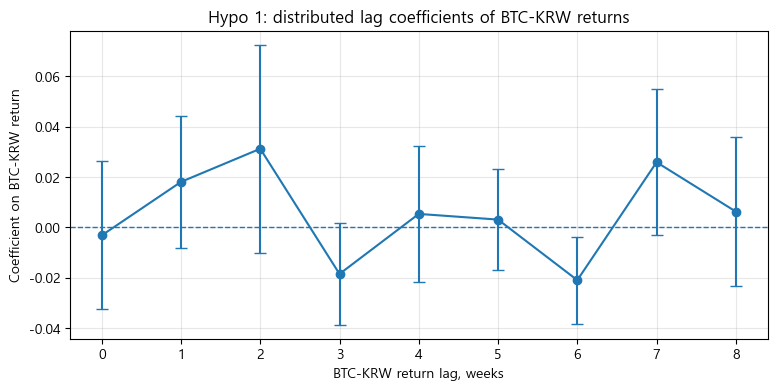

In [17]:
# ============================================================
# 4. Distributed Lag Regression: Hypo 1 메인 검정
#    gpu_ret_t = BTC lag 0~8 + FX + NVDA + GPU lag 1 + error
# ============================================================

h1_reg = h1[reg_cols].dropna().copy()

formula = (
    "gpu_ret ~ "
    + " + ".join(btc_lag_cols)
    + " + fx_ret + nvda_ret + gpu_ret_l1"
)

h1_model = smf.ols(formula, data=h1_reg).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": HAC_LAG},
)

print(h1_model.summary())

coef_table = pd.DataFrame({
    "term": h1_model.params.index,
    "coef": h1_model.params.values,
    "se_HAC": h1_model.bse.values,
    "t_HAC": h1_model.tvalues.values,
    "p_value_HAC": h1_model.pvalues.values,
})

btc_coef = coef_table[coef_table["term"].isin(btc_lag_cols)].copy()
btc_coef["lag_week"] = btc_coef["term"].str.extract(r"l(\d+)").astype(int)
btc_coef = btc_coef.sort_values("lag_week")

print("BTC lag coefficient table")
display(btc_coef.round(5))

coef_table.to_csv(H1_OUT / "h1_distributed_lag_coefficients.csv", index=False)
btc_coef.to_csv(H1_OUT / "h1_btc_lag_coefficients.csv", index=False)

plt.figure(figsize=(9, 4))
plt.errorbar(
    btc_coef["lag_week"],
    btc_coef["coef"],
    yerr=1.96 * btc_coef["se_HAC"],
    marker="o",
    capsize=4,
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Hypo 1: distributed lag coefficients of BTC-KRW returns")
plt.xlabel("BTC-KRW return lag, weeks")
plt.ylabel("Coefficient on BTC-KRW return")
plt.grid(True, alpha=0.3)
plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>5. BTC lag 공동 유의성 검정 + VIF 점검</mark></b></span><br><br>
<b>[왜 공동 유의성 검정을 하는가]</b><br>
BTC 효과는 한 주 lag에만 집중되지 않고 여러 주에 분산될 수 있다. 따라서 개별 p-value만 보면 전체 BTC 시차 효과를 놓칠 수 있다. 그래서 <b>H0: btc_lag_0 = ... = btc_lag_8 = 0</b>이라는 공동 귀무가설을 검정한다.<br><br>
<b>[왜 VIF를 확인하는가]</b><br>
BTC, NVDA, 환율은 특정 시장 국면에서 함께 움직일 수 있다. 다중공선성이 크면 계수 자체가 틀리는 것은 아니지만 표준오차가 커져 유의성이 약해질 수 있다. 그래서 <b>core VIF</b>로 핵심 통제변수 간 중복성을 점검한다.<br><br>
<b>[실행 후 해석]</b><br>
• 공동 유의성 p-value가 작으면 BTC lag 전체가 GPU 수익률을 설명하는 데 통계적으로 유의하다고 해석한다.<br>
• VIF가 높으면 “BTC 효과가 없다”가 아니라 “BTC와 통제변수가 동시에 움직여 계수 추정의 불확실성이 커졌다”고 해석한다.
</div>

In [18]:
# ============================================================
# 5. BTC lag 공동 유의성 검정 + 다중공선성 VIF 점검
# ============================================================

joint_hypothesis = ", ".join([f"{col} = 0" for col in btc_lag_cols])
joint_test = h1_model.f_test(joint_hypothesis)

joint_result = pd.DataFrame([{
    "hypothesis": f"btc_krw_ret_l0 ~ btc_krw_ret_l{MAX_LAG} jointly zero",
    "F_stat": float(np.asarray(joint_test.fvalue)),
    "p_value": float(np.asarray(joint_test.pvalue)),
    "df_num": float(joint_test.df_num),
    "df_denom": float(joint_test.df_denom),
}])

print("BTC lag 공동 유의성 검정")
display(joint_result)
joint_result.to_csv(H1_OUT / "h1_btc_lag_joint_test.csv", index=False)


def make_vif_table(df, cols):
    X = sm.add_constant(df[cols].astype(float))
    rows = []
    for i, col in enumerate(X.columns):
        if col == "const":
            continue
        rows.append({
            "variable": col,
            "VIF": variance_inflation_factor(X.values, i),
        })
    return pd.DataFrame(rows).sort_values("VIF", ascending=False)

# 핵심 통제변수 간 VIF: BTC, FX, NVDA가 서로 너무 강하게 겹치는지 확인
vif_core = make_vif_table(h1_reg, ["btc_krw_ret_l0", "fx_ret", "nvda_ret", "gpu_ret_l1"])

# 전체 회귀식 VIF: BTC lag끼리는 시계열상 서로 겹치므로 높게 나올 수 있다.
vif_full = make_vif_table(h1_reg, btc_lag_cols + ["fx_ret", "nvda_ret", "gpu_ret_l1"])

print("Core VIF: BTC contemporaneous return, FX, NVDA, GPU lag")
display(vif_core.round(3))

print("Full model VIF: includes all BTC lags")
display(vif_full.round(3))

vif_core.to_csv(H1_OUT / "h1_vif_core.csv", index=False)
vif_full.to_csv(H1_OUT / "h1_vif_full.csv", index=False)

BTC lag 공동 유의성 검정


,hypothesis,F_stat,p_value,df_num,df_denom
0,btc_krw_ret_l0 ~ btc_krw_ret_l8 jointly zero,1.701005,0.101684,9.0,83.0


Core VIF: BTC contemporaneous return, FX, NVDA, GPU lag


,variable,VIF
0,btc_krw_ret_l0,1.237
3,gpu_ret_l1,1.167
2,nvda_ret,1.096
1,fx_ret,1.038


Full model VIF: includes all BTC lags


,variable,VIF
2,btc_krw_ret_l2,1.433
4,btc_krw_ret_l4,1.432
0,btc_krw_ret_l0,1.411
1,btc_krw_ret_l1,1.389
3,btc_krw_ret_l3,1.388
5,btc_krw_ret_l5,1.281
7,btc_krw_ret_l7,1.277
6,btc_krw_ret_l6,1.259
11,gpu_ret_l1,1.241
10,nvda_ret,1.241


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>6. VAR 기반 다변량 Granger causality 보조 검정</mark></b></span><br><br>
<b>[왜 이 기법을 쓰는가]</b><br>
단순 Granger test는 GPU와 BTC 두 변수만 넣는 이변량 검정이라, 환율과 NVDA를 통제하지 못한다. 메인 회귀에서 통제변수를 넣어놓고 보조 검정에서는 빼면 논리가 약해진다. 따라서 <b>GPU, BTC, FX, NVDA</b>를 함께 넣는 VAR 기반 Granger 검정을 사용한다.<br><br>
<b>[해석 제한]</b><br>
Granger causality는 경제적 인과관계 증명이 아니다. 정확한 표현은 “BTC 수익률이 GPU 수익률의 <b>예측적 선행지표</b>인지 확인했다”이다.<br><br>
<b>[실행 후 해석]</b><br>
p-value가 작으면 환율과 NVDA를 포함한 다변량 시계열 구조 안에서도 BTC 과거값이 GPU 수익률 예측에 추가 정보를 제공한다고 해석한다.
</div>

In [19]:
# ============================================================
# 6. VAR 기반 다변량 Granger causality 보조 검정
#    단순 이변량 Granger가 아니라 FX, NVDA를 함께 포함한다.
#    해석은 인과 증명이 아니라 "예측적 선행성"으로 제한한다.
# ============================================================

var_data = h1[["gpu_ret", "btc_krw_ret", "fx_ret", "nvda_ret"]].dropna().copy()

var_fit = VAR(var_data).fit(maxlags=MAX_LAG, ic="aic")
if var_fit.k_ar == 0:
    var_fit = VAR(var_data).fit(maxlags=1)

btc_to_gpu = var_fit.test_causality(
    caused="gpu_ret",
    causing=["btc_krw_ret"],
    kind="f",
)

var_result = pd.DataFrame([{
    "selected_lag": int(var_fit.k_ar),
    "test": "VAR Granger causality: BTC-KRW return -> GPU return | FX, NVDA included",
    "statistic": float(btc_to_gpu.test_statistic),
    "p_value": float(btc_to_gpu.pvalue),
    "df": str(btc_to_gpu.df),
    "interpretation_limit": "predictive precedence only; not structural/economic causality",
}])

print("VAR-based multivariate Granger causality test")
display(var_result)
var_result.to_csv(H1_OUT / "h1_var_granger_btc_to_gpu.csv", index=False)

VAR-based multivariate Granger causality test


,selected_lag,test,statistic,p_value,df,interpretation_limit
0,1,VAR Granger causality: BTC-KRW return -> GPU r...,2.545232,0.111425,"(1, 396)",predictive precedence only; not structural/eco...


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>7. 장기 관계 분석: ADF + Engle-Granger Cointegration</mark></b></span><br><br>
<b>[왜 이 기법을 쓰는가]</b><br>
단기 분석은 수익률을 사용하지만, 장기 관계는 가격지수 level에서 확인해야 한다. 다만 level 시계열은 비정상일 수 있으므로 먼저 ADF 검정으로 단위근 여부를 확인하고, 두 series가 I(1)에 가까울 때 Engle-Granger 공적분 검정을 수행한다.<br><br>
<b>[통계적 의미]</b><br>
공적분이 있다는 것은 GPU 가격지수와 BTC 가격이 각각 비정상이어도 둘의 특정 선형결합은 안정적일 수 있다는 뜻이다. 즉 단기적으로는 벗어나도 장기적으로 같이 움직이는 균형관계가 있을 수 있다.<br><br>
<b>[실행 후 해석]</b><br>
• level ADF에서 비정상, diff ADF에서 정상에 가까우면 수익률 기반 단기 분석이 적절하다는 근거가 된다.<br>
• Engle-Granger p-value가 작으면 장기 균형관계 가능성이 있다.<br>
• 공적분이 약하면 장기 균형 주장은 하지 않고 단기 lag 관계 중심으로 결론을 내린다.
</div>

In [20]:
# ============================================================
# 7. 장기 관계 분석: ADF + Engle-Granger Cointegration
#    level 관계는 idx_all_w['GPU_ALL']와 BTC-KRW log level로 검정한다.
# ============================================================

level_h1 = (
    idx_all_w[[GPU_RET_COL]]
    .rename(columns={GPU_RET_COL: "gpu_index"})
)

level_h1 = (
    level_h1
    .join(mkt_log_level_w[["btc_krw", "usdkrw", "nvda"]], how="inner")
    .dropna()
    .copy()
)

level_h1["log_gpu_index"] = np.log(level_h1["gpu_index"])
level_h1 = level_h1.rename(columns={
    "btc_krw": "log_btc_krw",
    "usdkrw": "log_usdkrw",
    "nvda": "log_nvda",
})


def adf_rows(series_dict):
    rows = []
    for name, s in series_dict.items():
        stat, p_value, usedlag, nobs, crit, icbest = adfuller(s.dropna(), autolag="AIC")
        rows.append({
            "series": name,
            "adf_stat": stat,
            "p_value": p_value,
            "used_lag": usedlag,
            "nobs": nobs,
            "crit_1pct": crit["1%"],
            "crit_5pct": crit["5%"],
            "crit_10pct": crit["10%"],
        })
    return pd.DataFrame(rows)

adf_level = adf_rows({
    "log_gpu_index": level_h1["log_gpu_index"],
    "log_btc_krw": level_h1["log_btc_krw"],
})

adf_diff = adf_rows({
    "d_log_gpu_index": level_h1["log_gpu_index"].diff(),
    "d_log_btc_krw": level_h1["log_btc_krw"].diff(),
})

coint_stat, coint_p, coint_crit = coint(
    level_h1["log_gpu_index"],
    level_h1["log_btc_krw"],
)

coint_result = pd.DataFrame([{
    "test": "Engle-Granger cointegration: log GPU index ~ log BTC-KRW",
    "stat": coint_stat,
    "p_value": coint_p,
    "crit_1pct": coint_crit[0],
    "crit_5pct": coint_crit[1],
    "crit_10pct": coint_crit[2],
}])

print("ADF test on levels")
display(adf_level.round(4))
print("ADF test on first differences")
display(adf_diff.round(4))
print("Engle-Granger cointegration test")
display(coint_result.round(4))

level_h1.to_csv(H1_OUT / "h1_level_dataset.csv")
adf_level.to_csv(H1_OUT / "h1_adf_level.csv", index=False)
adf_diff.to_csv(H1_OUT / "h1_adf_diff.csv", index=False)
coint_result.to_csv(H1_OUT / "h1_engle_granger_coint.csv", index=False)

ADF test on levels


,series,adf_stat,p_value,used_lag,nobs,crit_1pct,crit_5pct,crit_10pct
0,log_gpu_index,-2.3802,0.1474,4,102,-3.4961,-2.8903,-2.5821
1,log_btc_krw,-1.5037,0.5317,1,105,-3.4942,-2.8895,-2.5817


ADF test on first differences


,series,adf_stat,p_value,used_lag,nobs,crit_1pct,crit_5pct,crit_10pct
0,d_log_gpu_index,-4.7189,0.0001,1,104,-3.4949,-2.8898,-2.5818
1,d_log_btc_krw,-7.8661,0.0000,0,105,-3.4942,-2.8895,-2.5817


Engle-Granger cointegration test


,test,stat,p_value,crit_1pct,crit_5pct,crit_10pct
0,Engle-Granger cointegration: log GPU index ~ l...,-2.3553,0.3463,-4.0027,-3.3944,-3.0847


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>8. ECM: AIC/BIC 기준 lag 선택</mark></b></span><br><br>
<b>[왜 ECM을 쓰는가]</b><br>
공적분 관계가 존재할 가능성이 있으면, 단기 수익률 변화와 장기 균형 이탈분을 한 모델에서 함께 볼 수 있다. ECM의 <b>ec_l1</b>은 직전 주에 장기 균형에서 얼마나 벗어났는지를 의미하고, 이 값이 다음 주 GPU 수익률에 반영되는지 확인한다.<br><br>
<b>[왜 lag를 고정하지 않는가]</b><br>
BTC 단기 lag를 임의로 0~3주로 고정하면 자의적이라는 지적을 받을 수 있다. 그래서 0~8주 후보 중 <b>AIC</b>로 메인 lag를 선택하고, <b>BIC</b>는 더 간결한 robustness 기준으로 함께 저장한다.<br><br>
<b>[실행 후 해석]</b><br>
• ec_l1 계수가 유의하고 음수이면 장기 균형에서 벗어난 GPU 가격이 다음 주에 균형 방향으로 조정되는 것으로 해석한다.<br>
• d_log_btc lag 계수가 유의하면 단기 BTC 충격이 GPU 가격 변화에 반영된다는 보조 증거가 된다.<br>
• Engle-Granger가 유의하지 않으면 ECM은 주된 결론이 아니라 보조 결과로만 제시한다.
</div>

In [21]:
# ============================================================
# 8. ECM: AIC/BIC 기준으로 BTC 단기 lag 길이 선택
#    공적분이 약하더라도, 결과표에는 "보조적 장기 조정 모형"으로 제시한다.
# ============================================================

coint_ols = smf.ols("log_gpu_index ~ log_btc_krw", data=level_h1).fit()

ecm = level_h1.copy()
ecm["ec_term"] = coint_ols.resid

ecm["d_log_gpu"] = ecm["log_gpu_index"].diff()
ecm["d_log_btc"] = ecm["log_btc_krw"].diff()
ecm["d_log_usdkrw"] = ecm["log_usdkrw"].diff()
ecm["d_log_nvda"] = ecm["log_nvda"].diff()
ecm["ec_l1"] = ecm["ec_term"].shift(1)

for k in range(MAX_LAG + 1):
    ecm[f"d_log_btc_l{k}"] = ecm["d_log_btc"].shift(k)

ecm_models = {}
ecm_select_rows = []

for K in range(0, MAX_LAG + 1):
    lag_cols = [f"d_log_btc_l{k}" for k in range(K + 1)]
    cols = ["d_log_gpu", "ec_l1", "d_log_usdkrw", "d_log_nvda"] + lag_cols
    reg = ecm[cols].dropna().copy()
    formula_k = "d_log_gpu ~ ec_l1 + " + " + ".join(lag_cols + ["d_log_usdkrw", "d_log_nvda"])
    fit_k = smf.ols(formula_k, data=reg).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": HAC_LAG},
    )
    ecm_models[K] = fit_k
    ecm_select_rows.append({
        "K_btc_lag": K,
        "n": int(len(reg)),
        "aic": fit_k.aic,
        "bic": fit_k.bic,
        "ec_l1_coef": fit_k.params.get("ec_l1", np.nan),
        "ec_l1_p": fit_k.pvalues.get("ec_l1", np.nan),
    })

ecm_select = pd.DataFrame(ecm_select_rows)
BEST_K_AIC = int(ecm_select.loc[ecm_select["aic"].idxmin(), "K_btc_lag"])
BEST_K_BIC = int(ecm_select.loc[ecm_select["bic"].idxmin(), "K_btc_lag"])
BEST_K = BEST_K_AIC

ecm_model = ecm_models[BEST_K]

print("ECM lag selection by AIC/BIC")
display(ecm_select.round(4))
print(f"Selected ECM BTC lag K by AIC = {BEST_K_AIC}")
print(f"Selected ECM BTC lag K by BIC = {BEST_K_BIC}")
print(ecm_model.summary())

ecm_coef = pd.DataFrame({
    "term": ecm_model.params.index,
    "coef": ecm_model.params.values,
    "se_HAC": ecm_model.bse.values,
    "t_HAC": ecm_model.tvalues.values,
    "p_value_HAC": ecm_model.pvalues.values,
})

print("Selected ECM coefficients")
display(ecm_coef.round(5))

ecm.to_csv(H1_OUT / "h1_ecm_dataset.csv")
ecm_select.to_csv(H1_OUT / "h1_ecm_lag_selection.csv", index=False)
ecm_coef.to_csv(H1_OUT / "h1_ecm_coefficients.csv", index=False)

ECM lag selection by AIC/BIC


,K_btc_lag,n,aic,bic,ec_l1_coef,ec_l1_p
0,0,106,-691.2231,-677.9059,-0.0022,0.9220
1,1,105,-681.7247,-665.8009,-0.0018,0.9363
2,2,104,-673.0095,-654.4988,0.0015,0.9554
3,3,103,-663.6543,-642.5765,0.0026,0.9226
4,4,102,-654.9523,-631.3275,0.0055,0.8270
5,5,101,-645.8131,-619.6619,0.0069,0.7700
6,6,100,-636.5885,-607.9316,0.0052,0.8204
7,7,99,-627.7579,-596.6165,0.0075,0.7439
8,8,98,-618.9195,-585.3149,0.0074,0.7438


Selected ECM BTC lag K by AIC = 0
Selected ECM BTC lag K by BIC = 0
                            OLS Regression Results                            
Dep. Variable:              d_log_gpu   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     1.021
Date:                Sun, 03 May 2026   Prob (F-statistic):              0.400
Time:                        17:20:39   Log-Likelihood:                 350.61
No. Observations:                 106   AIC:                            -691.2
Df Residuals:                     101   BIC:                            -677.9
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

,term,coef,se_HAC,t_HAC,p_value_HAC
0,Intercept,0.00138,0.00150,0.92034,0.35739
1,ec_l1,-0.00220,0.02241,-0.09797,0.92196
2,d_log_btc_l0,-0.04320,0.02703,-1.59806,0.11003
3,d_log_usdkrw,-0.07285,0.12043,-0.60487,0.54527
4,d_log_nvda,0.00468,0.01162,0.40322,0.68678


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>9. Hypo 1 최종 요약 테이블</mark></b></span><br><br>
<b>[왜 요약 테이블을 저장하는가]</b><br>
발표와 보고서에서는 전체 회귀표를 모두 보여주기 어렵다. 따라서 핵심 결과인 최대 lag 상관, BTC lag 공동 유의성, VIF, VAR-Granger, 공적분, ECM 선택 lag, ETC 보조 EDA 결과를 하나의 summary csv로 저장한다.<br><br>
<b>[최종 결론 해석 방식]</b><br>
• 단기 주장은 <b>lag correlation + distributed lag regression + joint F-test</b> 중심으로 한다.<br>
• Granger는 “예측적 선행성”으로만 표현한다.<br>
• 장기 주장은 Engle-Granger가 유의할 때만 강하게 말한다.<br>
• ETC-KRW는 메인 검정 변수가 아니라, BTC를 crypto sentiment proxy로 쓰는 논리를 보조하거나 한계로 설명하는 EDA로만 사용한다.
</div>

In [22]:
# ============================================================
# 9. Hypo 1 최종 요약 테이블 저장
# ============================================================

max_corr_row = lag_corr.loc[lag_corr["corr_gpu_btc"].abs().idxmax()]
max_partial_row = partial_corr.loc[partial_corr["partial_corr_gpu_btc"].abs().idxmax()]
max_etc_row = etc_lag_corr.loc[etc_lag_corr["corr_gpu_etc"].abs().idxmax()]

summary_rows = [
    {
        "block": "lag_correlation",
        "main_result": "max_abs_corr_lag_week",
        "value": int(max_corr_row["lag_week"]),
        "detail": float(max_corr_row["corr_gpu_btc"]),
    },
    {
        "block": "partial_correlation",
        "main_result": "max_abs_partial_corr_lag_week",
        "value": int(max_partial_row["lag_week"]),
        "detail": float(max_partial_row["partial_corr_gpu_btc"]),
    },
    {
        "block": "distributed_lag_regression",
        "main_result": "btc_lags_joint_p_value",
        "value": float(joint_result.loc[0, "p_value"]),
        "detail": f"H0: btc_krw_ret_l0 ... btc_krw_ret_l{MAX_LAG} are all zero",
    },
    {
        "block": "multicollinearity",
        "main_result": "max_core_vif",
        "value": float(vif_core["VIF"].max()),
        "detail": "VIF among btc_krw_ret_l0, fx_ret, nvda_ret, gpu_ret_l1",
    },
    {
        "block": "var_granger",
        "main_result": "btc_to_gpu_p_value_with_controls",
        "value": float(var_result.loc[0, "p_value"]),
        "detail": f"VAR selected lag = {int(var_result.loc[0, 'selected_lag'])}; FX and NVDA included; predictive precedence only",
    },
    {
        "block": "cointegration",
        "main_result": "engle_granger_p_value",
        "value": float(coint_result.loc[0, "p_value"]),
        "detail": "log GPU index and log BTC-KRW",
    },
    {
        "block": "ecm",
        "main_result": "selected_btc_lag_by_aic",
        "value": BEST_K_AIC,
        "detail": f"BIC selected lag = {BEST_K_BIC}; ECM includes ec_l1, d_log_usdkrw, d_log_nvda",
    },
    {
        "block": "etc_eda",
        "main_result": "btc_etc_return_corr",
        "value": float(crypto_corr),
        "detail": "ETC-KRW is used only as GPU-mining-domain EDA, not main regressor",
    },
    {
        "block": "etc_eda",
        "main_result": "max_abs_corr_gpu_etc_lag_week",
        "value": int(max_etc_row["lag_week"]),
        "detail": float(max_etc_row["corr_gpu_etc"]),
    },
]

h1_summary = pd.DataFrame(summary_rows)

print("Hypo 1 summary")
display(h1_summary)

h1_summary.to_csv(H1_OUT / "h1_summary.csv", index=False)
print("Hypo 1 outputs saved to:", H1_OUT)

Hypo 1 summary


,block,main_result,value,detail
0,lag_correlation,max_abs_corr_lag_week,0.000000,-0.221623
1,partial_correlation,max_abs_partial_corr_lag_week,2.000000,0.185539
2,distributed_lag_regression,btc_lags_joint_p_value,0.101684,H0: btc_krw_ret_l0 ... btc_krw_ret_l8 are all ...
3,multicollinearity,max_core_vif,1.236976,"VIF among btc_krw_ret_l0, fx_ret, nvda_ret, gp..."
4,var_granger,btc_to_gpu_p_value_with_controls,0.111425,VAR selected lag = 1; FX and NVDA included; pr...
5,cointegration,engle_granger_p_value,0.346307,log GPU index and log BTC-KRW
6,ecm,selected_btc_lag_by_aic,0.000000,"BIC selected lag = 0; ECM includes ec_l1, d_lo..."
7,etc_eda,btc_etc_return_corr,0.745652,"ETC-KRW is used only as GPU-mining-domain EDA,..."
8,etc_eda,max_abs_corr_gpu_etc_lag_week,0.000000,-0.192636


Hypo 1 outputs saved to: outputs\hypo1


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>Hypothesis 1 보고서용 해석 문장</mark></b></span><br><br>

<b>[방법론 요약]</b><br>
전체 GPU 가격지수의 주간 로그수익률을 종속변수로 두고, BTC-KRW 수익률의 현재값과 1~8주 lag를 포함한 distributed lag regression을 수행하였다. 이때 USD/KRW 환율 수익률과 NVDA 수익률을 통제하여 원화 환율 효과와 AI/반도체 수요 효과를 분리하였고, HAC 표준오차를 사용해 주간 시계열의 자기상관과 이분산 가능성을 보정하였다.<br><br>

<b>[결론 해석 템플릿]</b><br>
• <b>BTC lag 공동 유의성 p-value &lt; 0.05</b>이면: BTC 가격 변동의 현재 및 과거값들이 GPU 가격 변동을 공동으로 설명하는 통계적 근거가 있다고 해석한다.<br>
• <b>BTC lag 공동 유의성 p-value ≥ 0.05</b>이면: 환율과 NVDA를 통제한 뒤에는 BTC 변동이 GPU 가격 변동을 설명한다는 강한 근거를 찾기 어렵다고 해석한다.<br>
• <b>VAR-Granger p-value &lt; 0.05</b>이면: BTC 수익률이 GPU 수익률의 예측적 선행지표일 가능성이 있다고 표현하되, 경제적 인과관계라고 말하지 않는다.<br>
• <b>Engle-Granger p-value &lt; 0.05</b>이면: GPU 가격지수와 BTC 가격 사이의 장기 균형관계 가능성을 언급할 수 있다. 유의하지 않으면 장기 관계 주장은 하지 않고 단기 lag 관계 중심으로 결론을 낸다.<br>
• <b>ETC-KRW EDA</b>는 BTC를 crypto sentiment proxy로 쓰는 논리를 보조하거나, GPU-mining coin을 직접 proxy로 쓰지 못한 한계로 설명한다. 메인 가설 검정의 결론은 BTC distributed lag regression에서 판단한다.<br><br>

<span style="color: #e53e3e; font-size: 18px;"><b>발표 시 주의: “BTC가 GPU 가격을 인과적으로 상승시켰다”가 아니라 “BTC 수익률이 GPU 수익률과 특정 시차에서 통계적으로 동행/선행했는지 검정했다”라고 말해야 한다.</b></span>
</div>